# Exploratory Data Analysis (EDA)

In [114]:
import pandas as pd
df = pd.read_csv('Manufacturing_Downtime_Dataset.csv')

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("Manufacturing_Downtime_Dataset.csv")

df.head()

,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(?C),Spindle_Bearing_Temperature(?C),Spindle_Vibration(?m),Tool_Vibration(?m),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,335.0,24.055326,3.58,Machine_Failure
1,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,125.33,4.936892,6.196733,35.3,47.4,34.6,1.382,25.274,19856.0,368.0,14.202890,2.68,Machine_Failure
2,31-12-2021,Makino-L3-Unit1-2015,Shopfloor-L3,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,325.0,24.049267,3.55,Machine_Failure
3,31-05-2022,Makino-L2-Unit1-2015,Shopfloor-L2,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,360.0,25.860029,3.55,Machine_Failure
4,31-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,60.51,6.893182,6.141238,4.1,47.3,31.4,0.983,25.516,26526.0,354.0,25.515874,3.55,Machine_Failure


In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Overall Failure Rate: 50.60%


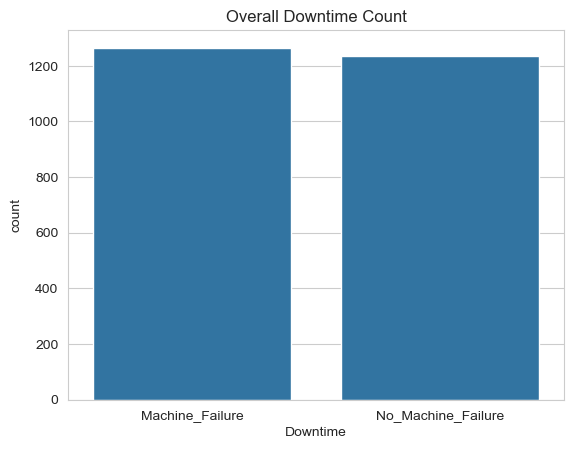

In [118]:
# What is the overall failure rate in the dataset?
failure_rate = (df["Downtime"] == "Machine_Failure").mean() * 100

print(f"Overall Failure Rate: {failure_rate:.2f}%")

sns.countplot(data=df, x="Downtime")
plt.title("Overall Downtime Count")
plt.show()

Machine_ID
Makino-L1-Unit1-2013    454
Makino-L3-Unit1-2015    415
Makino-L2-Unit1-2015    396
Name: count, dtype: int64


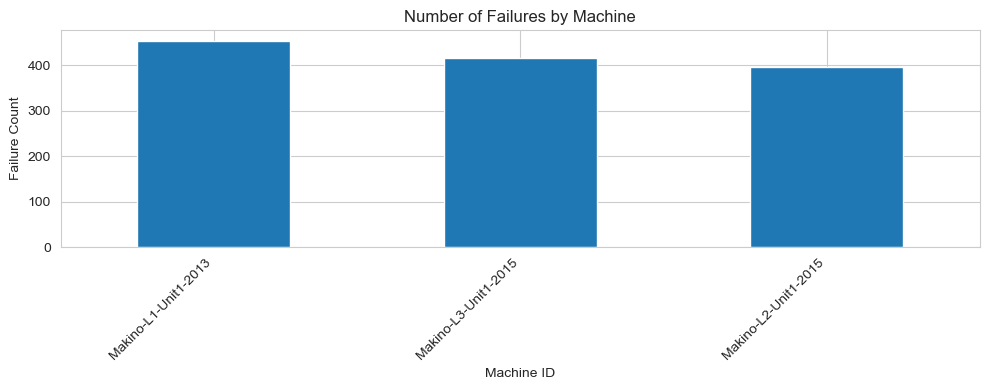

In [120]:
# Which machine experiences the highest number of failures?
# Which machine experiences the highest number of failures?

failure_df = df[df["Downtime"] == "Machine_Failure"]

machine_failures = failure_df["Machine_ID"].value_counts()

print(machine_failures)

machine_failures.plot(kind="bar", figsize=(10,4))
plt.title("Number of Failures by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Failure Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

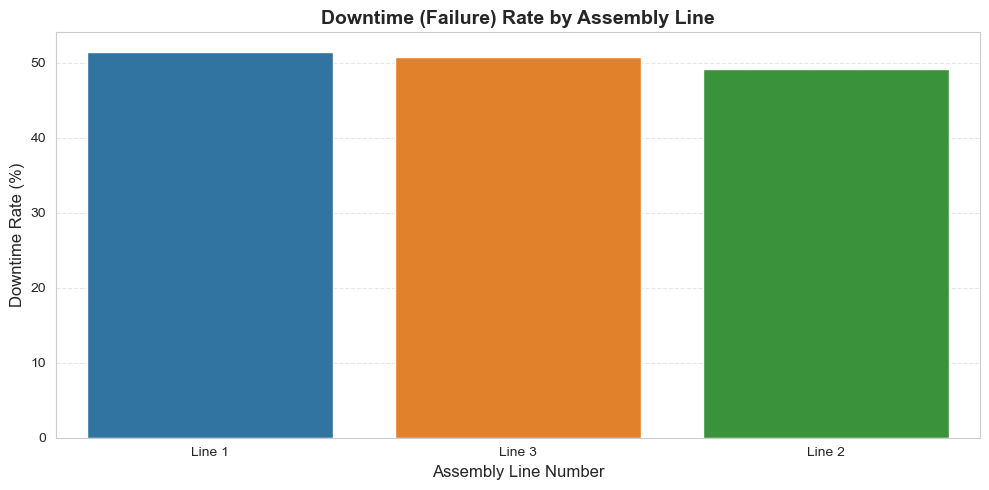

In [121]:
# Which assembly line has the highest downtime (failure) rate?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(
    data=line_rates, 
    x='assembly_line_no', 
    y='downtime_rate_pct', 
    hue='assembly_line_no',
    legend=False,
)
plt.title('Downtime (Failure) Rate by Assembly Line', fontsize=14, fontweight='bold')
plt.xlabel('Assembly Line Number', fontsize=12)
plt.ylabel('Downtime Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


 Coolant_Temperature
Average during failure: 19.983
Average without failure: 17.088


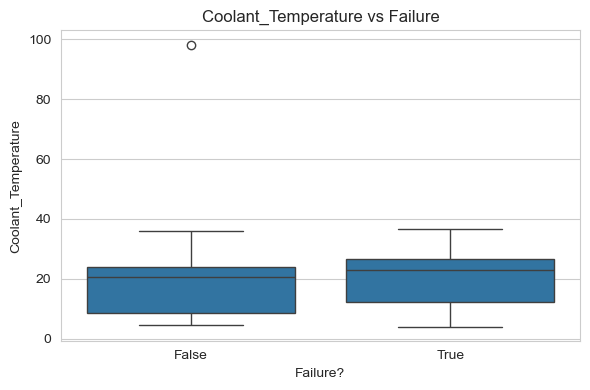


 Hydraulic_Oil_Temperature(?C)
Average during failure: 47.571
Average without failure: 47.667


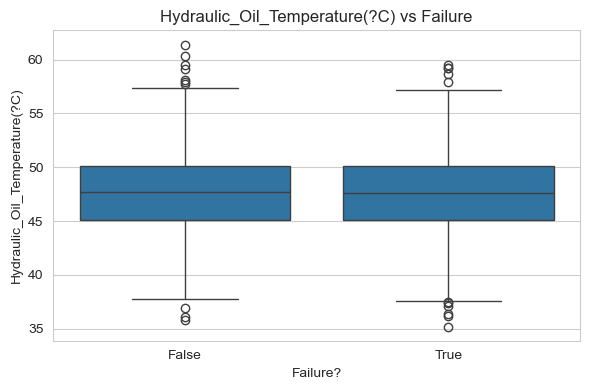


 Spindle_Bearing_Temperature(?C)
Average during failure: 34.991
Average without failure: 35.138


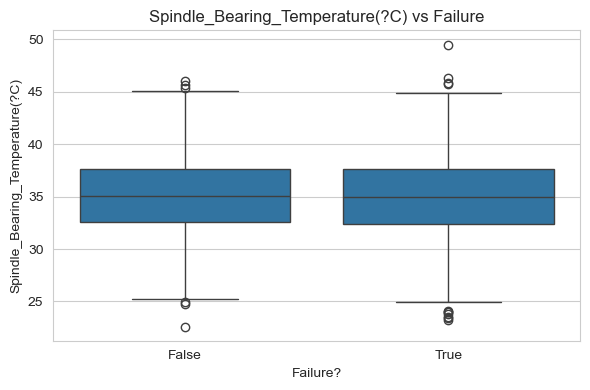

In [123]:
temp_cols = [
    "Coolant_Temperature",
    "Hydraulic_Oil_Temperature(?C)",
    "Spindle_Bearing_Temperature(?C)"
]

failure_df = df[df["Downtime"] == "Machine_Failure"]
normal_df = df[df["Downtime"] != "Machine_Failure"]

for col in temp_cols:
    print("\n", col)
    print("Average during failure:", round(failure_df[col].mean(), 3))
    print("Average without failure:", round(normal_df[col].mean(), 3))

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=df["Downtime"] == "Machine_Failure", y=col)
    plt.title(col + " vs Failure")
    plt.xlabel("Failure?")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


 Spindle_Vibration(?m)
Average during failure: 1.0037
Average without failure: 1.0151


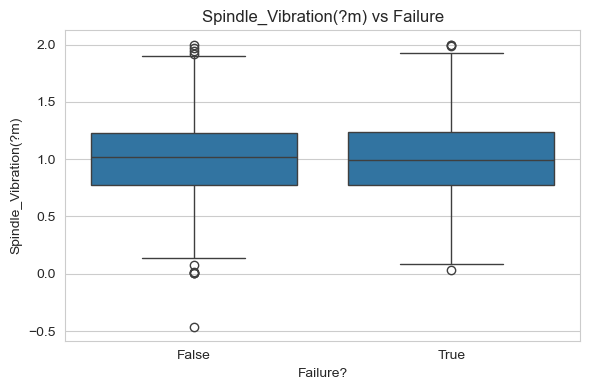


 Tool_Vibration(?m)
Average during failure: 25.3745
Average without failure: 25.4503


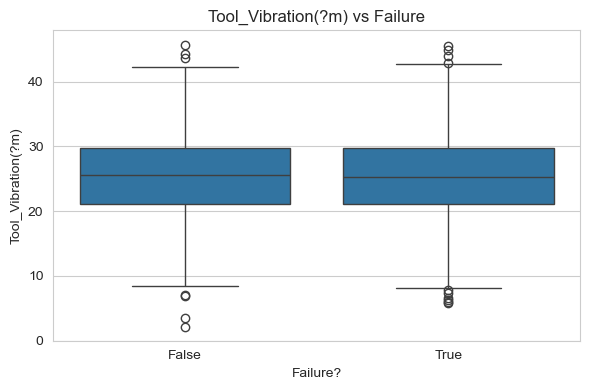

In [125]:
# Is vibration associated with machine failures?
vib_cols = ["Spindle_Vibration(?m)", "Tool_Vibration(?m)"]

failure_df = df[df["Downtime"] == "Machine_Failure"]
normal_df = df[df["Downtime"] != "Machine_Failure"]

for col in vib_cols:
    print("\n", col)
    print("Average during failure:", round(failure_df[col].mean(), 4))
    print("Average without failure:", round(normal_df[col].mean(), 4))

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=df["Downtime"] == "Machine_Failure", y=col)
    plt.title(col + " vs Failure")
    plt.xlabel("Failure?")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


 Hydraulic_Pressure(bar)
Average during failure: 84.76
Average without failure: 118.574


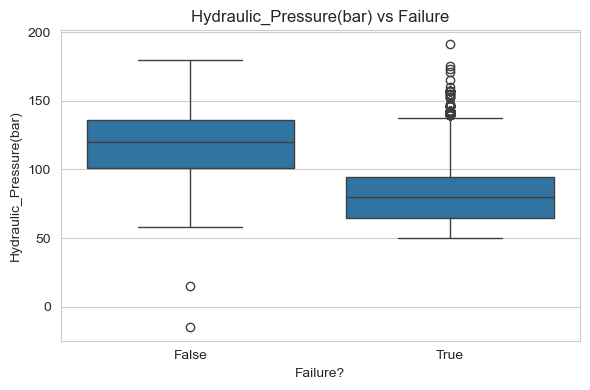


 Coolant_Pressure(bar)
Average during failure: 5.115
Average without failure: 4.772


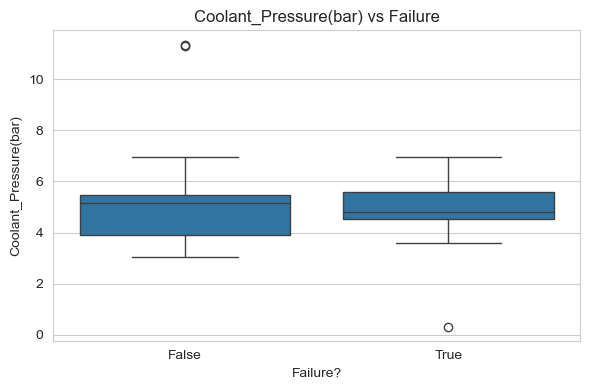


 Air_System_Pressure(bar)
Average during failure: 6.503
Average without failure: 6.495


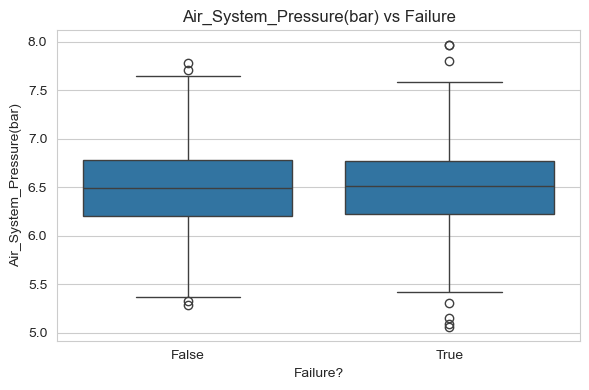

In [126]:
# What is the relationship between pressure measurements and machine failures?

pressure_cols = [
    "Hydraulic_Pressure(bar)",
    "Coolant_Pressure(bar)",
    "Air_System_Pressure(bar)"
]

failure_df = df[df["Downtime"] == "Machine_Failure"]
normal_df = df[df["Downtime"] != "Machine_Failure"]

for col in pressure_cols:
    print("\n", col)
    print("Average during failure:", round(failure_df[col].mean(), 3))
    print("Average without failure:", round(normal_df[col].mean(), 3))

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=df["Downtime"] == "Machine_Failure", y=col)
    plt.title(col + " vs Failure")
    plt.xlabel("Failure?")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

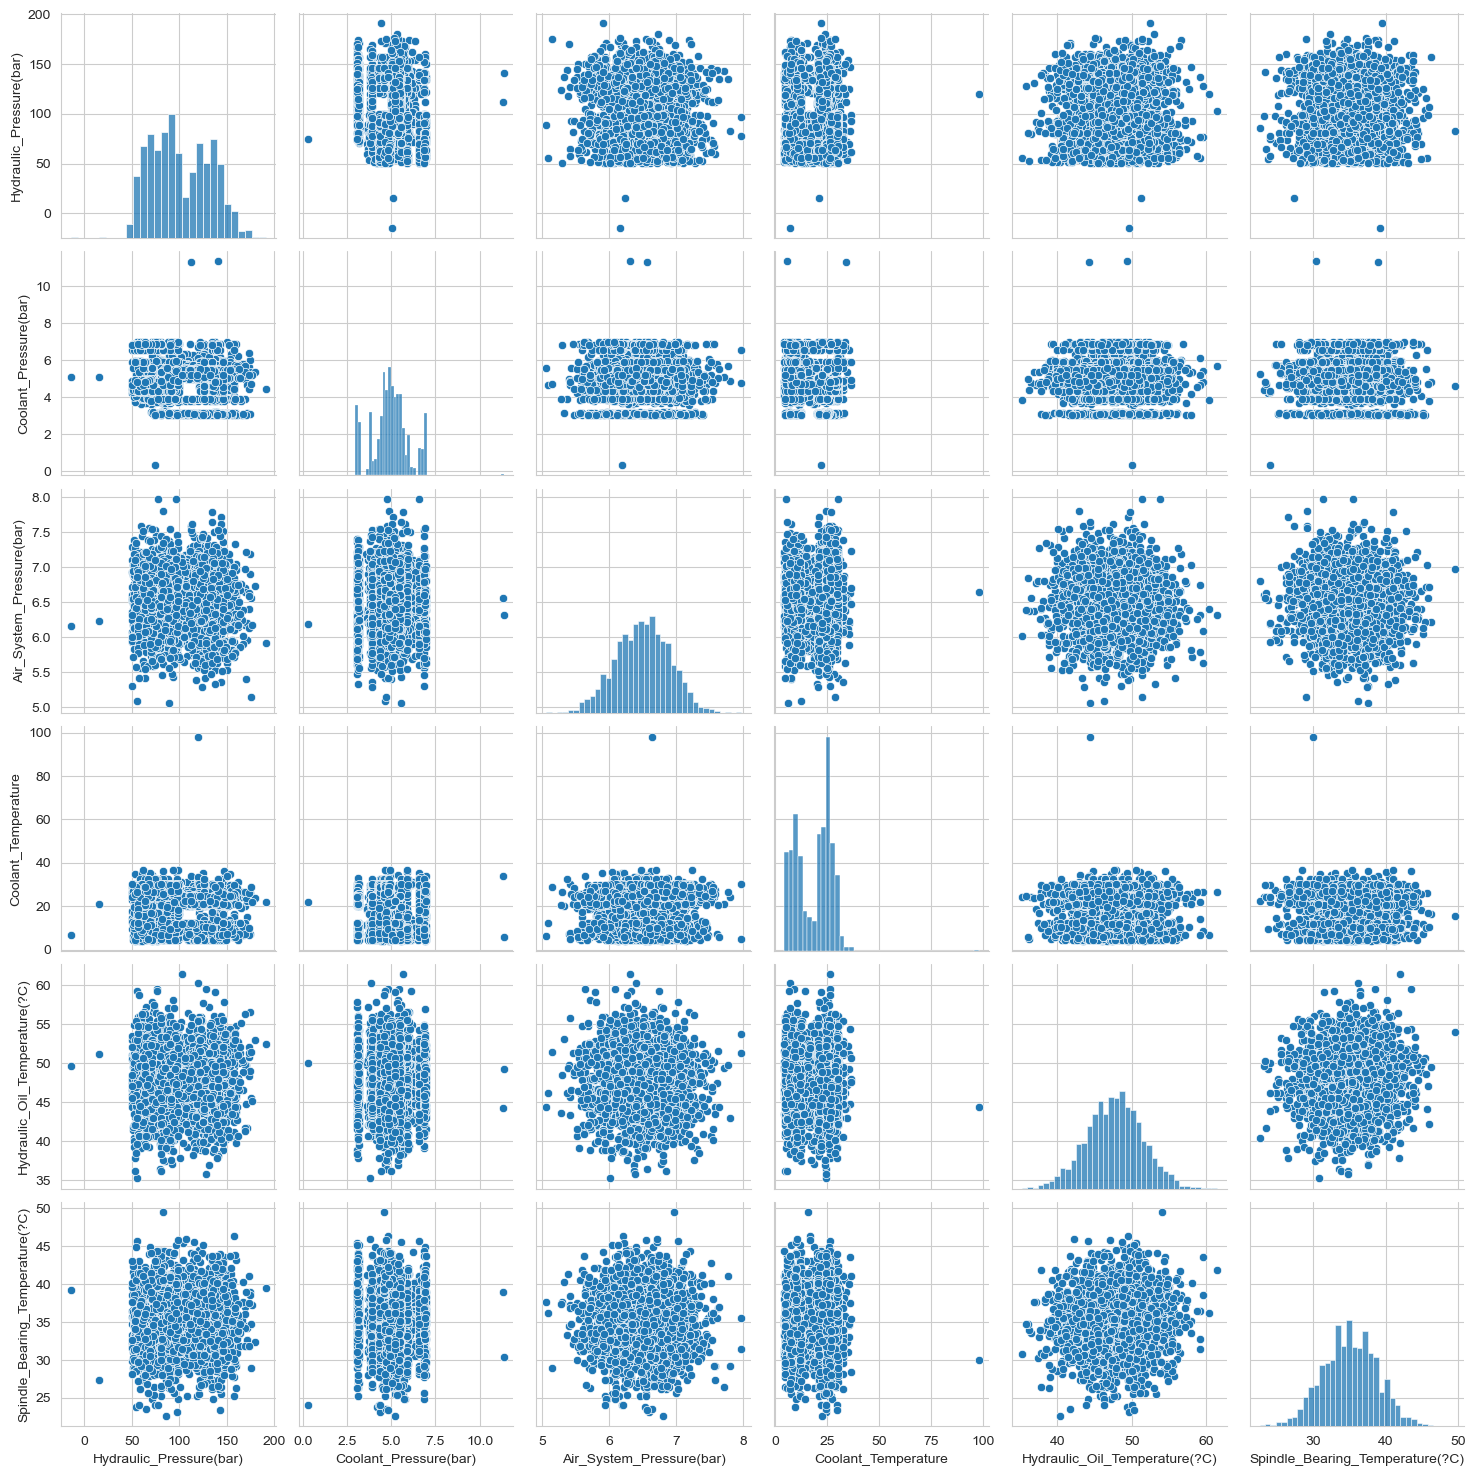

In [129]:
# Pairplot of all pressure and temperature variables

cols = [
    "Hydraulic_Pressure(bar)",
    "Coolant_Pressure(bar)",
    "Air_System_Pressure(bar)",
    "Coolant_Temperature",
    "Hydraulic_Oil_Temperature(?C)",
    "Spindle_Bearing_Temperature(?C)"
]

sns.pairplot(df[cols])
plt.show()

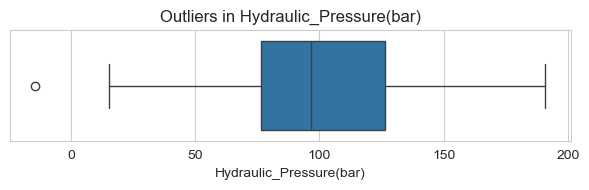

Hydraulic_Pressure(bar) | outlier count: 1 | failure rate among outliers: 0.0


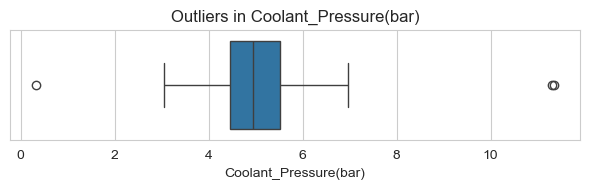

Coolant_Pressure(bar) | outlier count: 3 | failure rate among outliers: 0.333


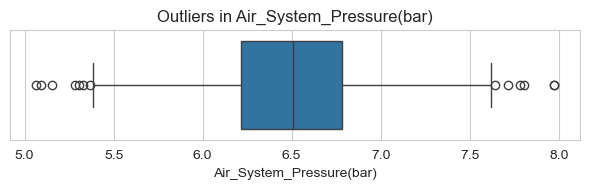

Air_System_Pressure(bar) | outlier count: 13 | failure rate among outliers: 0.538


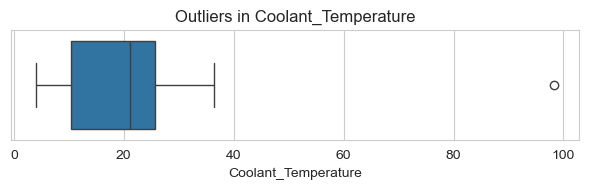

Coolant_Temperature | outlier count: 1 | failure rate among outliers: 0.0


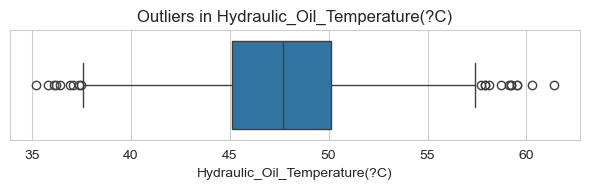

Hydraulic_Oil_Temperature(?C) | outlier count: 21 | failure rate among outliers: 0.524


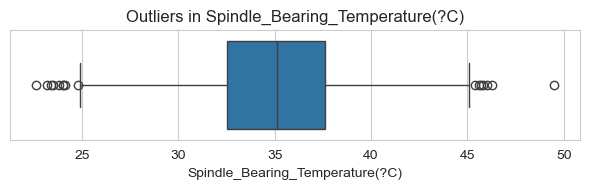

Spindle_Bearing_Temperature(?C) | outlier count: 16 | failure rate among outliers: 0.688


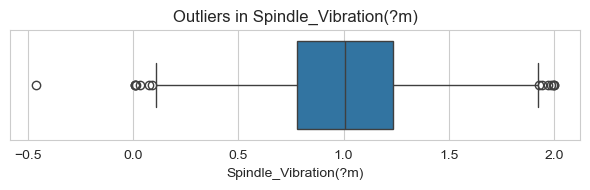

Spindle_Vibration(?m) | outlier count: 15 | failure rate among outliers: 0.4


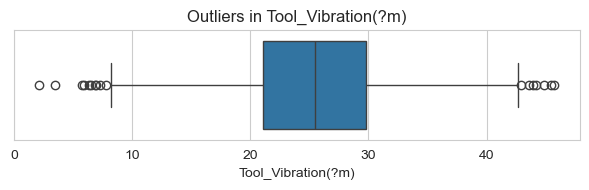

Tool_Vibration(?m) | outlier count: 17 | failure rate among outliers: 0.588


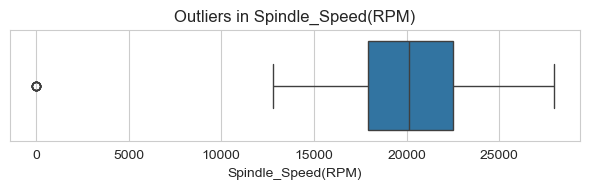

Spindle_Speed(RPM) | outlier count: 7 | failure rate among outliers: 1.0


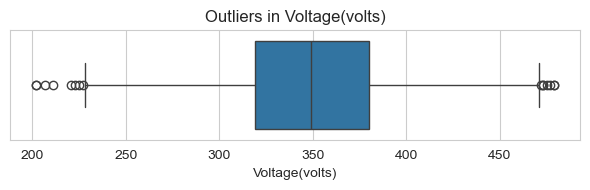

Voltage(volts) | outlier count: 15 | failure rate among outliers: 0.4


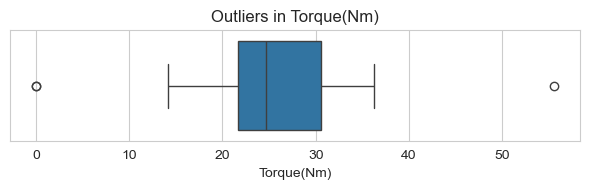

Torque(Nm) | outlier count: 3 | failure rate among outliers: 0.333


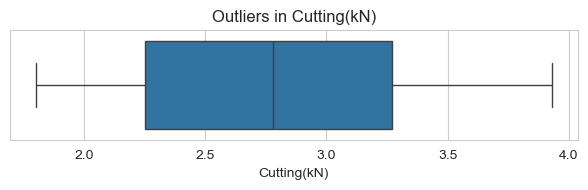

Cutting(kN) | outlier count: 0 | failure rate among outliers: nan


In [131]:
# Are there any significant outliers that may be linked to failures?

num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title("Outliers in " + col)
    plt.tight_layout()
    plt.show()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    outliers = df[(df[col] < low) | (df[col] > high)]
    print(col, "| outlier count:", len(outliers), "| failure rate among outliers:", round((outliers["Downtime"] == "Machine_Failure").mean(), 3))

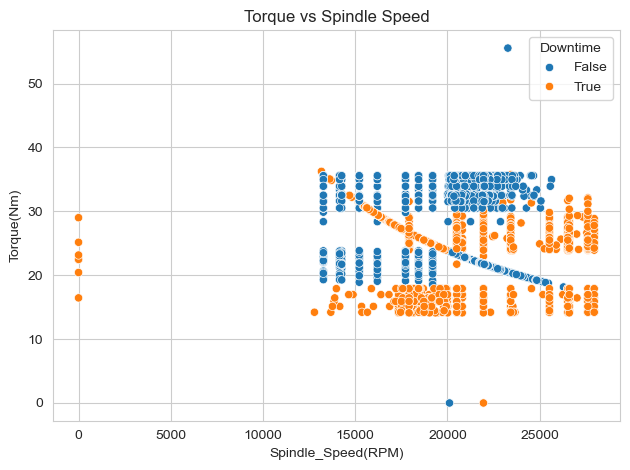

                    Spindle_Speed(RPM)  Torque(Nm)
Spindle_Speed(RPM)             1.00000    -0.19459
Torque(Nm)                    -0.19459     1.00000


In [132]:
# Is there a relationship between mechanical load (Torque vs. Spindle Speed) and downtime events?

sns.scatterplot(
    data=df,
    x="Spindle_Speed(RPM)",
    y="Torque(Nm)",
    hue=(df["Downtime"] == "Machine_Failure")
)
plt.title("Torque vs Spindle Speed")
plt.tight_layout()
plt.show()

print(df[["Spindle_Speed(RPM)", "Torque(Nm)"]].corr())

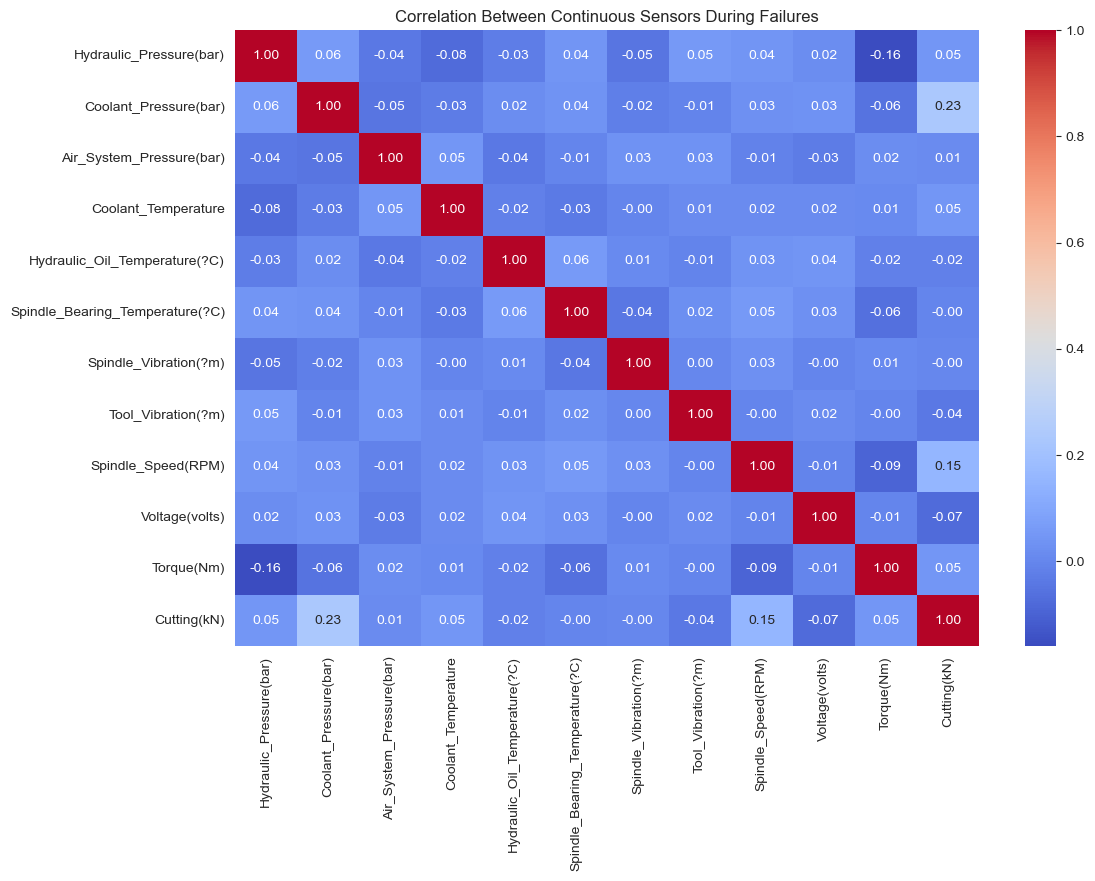

                                 Hydraulic_Pressure(bar)  \
Hydraulic_Pressure(bar)                             1.00   
Coolant_Pressure(bar)                               0.06   
Air_System_Pressure(bar)                           -0.04   
Coolant_Temperature                                -0.08   
Hydraulic_Oil_Temperature(?C)                      -0.03   
Spindle_Bearing_Temperature(?C)                     0.04   
Spindle_Vibration(?m)                              -0.05   
Tool_Vibration(?m)                                  0.05   
Spindle_Speed(RPM)                                  0.04   
Voltage(volts)                                      0.02   
Torque(Nm)                                         -0.16   
Cutting(kN)                                         0.05   

                                 Coolant_Pressure(bar)  \
Hydraulic_Pressure(bar)                           0.06   
Coolant_Pressure(bar)                             1.00   
Air_System_Pressure(bar)                     

In [135]:
# What is the overall correlation between all continuous sensors during failure events?

failure_df = df[df["Downtime"] == "Machine_Failure"]

numeric_cols = failure_df.select_dtypes(include=np.number)

correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Between Continuous Sensors During Failures")
plt.show()

# Correlation table

failure_df = df[df["Downtime"] == "Machine_Failure"]

correlation_matrix = failure_df.select_dtypes(include=np.number).corr()

print(correlation_matrix.round(2))

In [137]:
# Which sensor has the strongest relationship with failures?

numeric_cols = df.select_dtypes(include=np.number).columns
failure_numeric = (df["Downtime"] == "Machine_Failure").astype(int)
correlations = {}
for col in numeric_cols:
    correlations[col] = df[col].corr(failure_numeric)
corr_df = pd.Series(correlations).sort_values(key=abs, ascending=False)

print(corr_df)

Hydraulic_Pressure(bar)           -0.558218
Cutting(kN)                        0.450093
Torque(Nm)                        -0.408505
Spindle_Speed(RPM)                 0.275127
Coolant_Pressure(bar)              0.171678
Coolant_Temperature                0.169235
Spindle_Bearing_Temperature(?C)   -0.019472
Spindle_Vibration(?m)             -0.016665
Hydraulic_Oil_Temperature(?C)     -0.012647
Air_System_Pressure(bar)           0.009213
Tool_Vibration(?m)                -0.005889
Voltage(volts)                     0.005853
dtype: float64


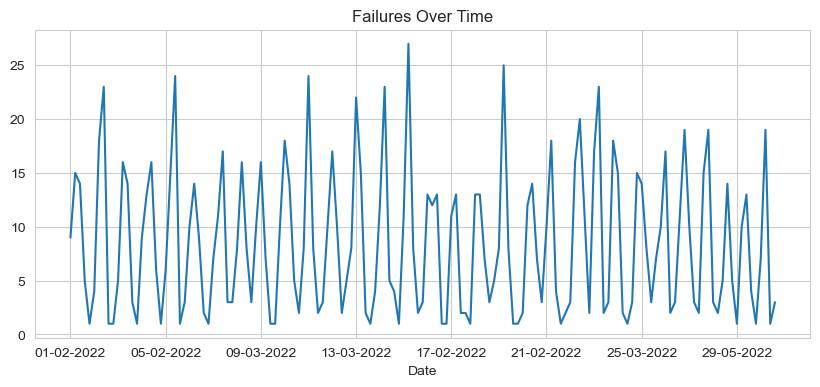

In [136]:
# Do failures increase over time?
daily_failures = df[df["Downtime"] == "Machine_Failure"].groupby("Date").size()

daily_failures.plot(figsize=(10,4))
plt.title("Failures Over Time")
plt.show()

# Statistical Data Analysis

In [140]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nFirst 5 rows:")
df.head()

Columns:
['Date', 'Machine_ID', 'Assembly_Line_No', 'Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(?C)', 'Spindle_Bearing_Temperature(?C)', 'Spindle_Vibration(?m)', 'Tool_Vibration(?m)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)', 'Downtime']

Data types:
Date                                object
Machine_ID                          object
Assembly_Line_No                    object
Hydraulic_Pressure(bar)            float64
Coolant_Pressure(bar)              float64
Air_System_Pressure(bar)           float64
Coolant_Temperature                float64
Hydraulic_Oil_Temperature(?C)      float64
Spindle_Bearing_Temperature(?C)    float64
Spindle_Vibration(?m)              float64
Tool_Vibration(?m)                 float64
Spindle_Speed(RPM)                 float64
Voltage(volts)                     float64
Torque(Nm)                         float64
Cutting(kN)                       

,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(?C),Spindle_Bearing_Temperature(?C),Spindle_Vibration(?m),Tool_Vibration(?m),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,335.0,24.055326,3.58,Machine_Failure
1,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,125.33,4.936892,6.196733,35.3,47.4,34.6,1.382,25.274,19856.0,368.0,14.202890,2.68,Machine_Failure
2,31-12-2021,Makino-L3-Unit1-2015,Shopfloor-L3,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,325.0,24.049267,3.55,Machine_Failure
3,31-05-2022,Makino-L2-Unit1-2015,Shopfloor-L2,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,360.0,25.860029,3.55,Machine_Failure
4,31-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,60.51,6.893182,6.141238,4.1,47.3,31.4,0.983,25.516,26526.0,354.0,25.515874,3.55,Machine_Failure


In [141]:
# Check failure distribution

failure_counts = df["Downtime"].value_counts()

print(failure_counts)

print("\nPercentages:")
print(round(df["Downtime"].value_counts(normalize=True) * 100, 2))

Downtime
Machine_Failure       1265
No_Machine_Failure    1235
Name: count, dtype: int64

Percentages:
Downtime
Machine_Failure       50.6
No_Machine_Failure    49.4
Name: proportion, dtype: float64


In [142]:
failure_df = df[df["Downtime"] == "Machine_Failure"]
normal_df = df[df["Downtime"] == "No_Machine_Failure"]

comparison = pd.DataFrame({
    "Failure Mean": failure_df.mean(numeric_only=True),
    "Normal Mean": normal_df.mean(numeric_only=True)
})

comparison["Difference"] = (
    comparison["Failure Mean"]
    - comparison["Normal Mean"]
)

comparison = comparison.sort_values(
    by="Difference",
    key=abs,
    ascending=False
)

print(comparison.round(3))

                                 Failure Mean  Normal Mean  Difference
Spindle_Speed(RPM)                  21319.361    19199.626    2119.736
Hydraulic_Pressure(bar)                84.760      118.574     -33.813
Torque(Nm)                             22.761       27.776      -5.015
Coolant_Temperature                    19.983       17.088       2.895
Cutting(kN)                             3.056        2.501       0.555
Voltage(volts)                        349.258      348.727       0.531
Coolant_Pressure(bar)                   5.115        4.772       0.342
Spindle_Bearing_Temperature(?C)        34.991       35.138      -0.147
Hydraulic_Oil_Temperature(?C)          47.571       47.667      -0.095
Tool_Vibration(?m)                     25.375       25.450      -0.076
Spindle_Vibration(?m)                   1.004        1.015      -0.011
Air_System_Pressure(bar)                6.503        6.495       0.008


In [ ]:
# Initial interpretation
Failed machines tend to run at higher spindle speeds.
Failed machines have much lower hydraulic pressure.
Failed machines have lower torque.
Failed machines have higher coolant temperatures.
Vibration appears to have very little difference.
Air system pressure appears almost identical. 

In [147]:
# Hyydrolic Pressure
from scipy.stats import ttest_ind

failure = df[df["Downtime"] == "Machine_Failure"]["Hydraulic_Pressure(bar)"].dropna()
normal = df[df["Downtime"] == "No_Machine_Failure"]["Hydraulic_Pressure(bar)"].dropna()

t_stat, p_value = ttest_ind(failure, normal)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -33.559122078353305
P-value: 5.31255500619395e-204


In [148]:
#Spindle Vibrations
from scipy.stats import ttest_ind

failure = df[df["Downtime"] == "Machine_Failure"]["Spindle_Speed(RPM)"].dropna()
normal = df[df["Downtime"] == "No_Machine_Failure"]["Spindle_Speed(RPM)"].dropna()

t_stat, p_value = ttest_ind(failure, normal)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 14.285621510753248
P-value: 1.4723497952948168e-44


In [149]:
#Torque
from scipy.stats import ttest_ind

failure = df[df["Downtime"] == "Machine_Failure"]["Torque(Nm)"].dropna()
normal = df[df["Downtime"] == "No_Machine_Failure"]["Torque(Nm)"].dropna()

t_stat, p_value = ttest_ind(failure, normal)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -22.27435019040883
P-value: 2.464871108329755e-100


In [151]:
# Coolant Temperature
from scipy.stats import ttest_ind

failure = df[df["Downtime"] == "Machine_Failure"]["Coolant_Temperature"].dropna()
normal = df[df["Downtime"] == "No_Machine_Failure"]["Coolant_Temperature"].dropna()

t_stat, p_value = ttest_ind(failure, normal)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.56151996405634
P-value: 1.9197907462855717e-17


In [152]:
#ANOVA: Do assembly lines differ?
from scipy.stats import f_oneway

for col in ["Hydraulic_Pressure(bar)", "Torque(Nm)", "Coolant_Temperature"]:

    groups = [
        group[col].dropna()
        for _, group in df.groupby("Assembly_Line_No")
    ]

    f_stat, p_value = f_oneway(*groups)

    print("\n", col)
    print("F-statistic:", round(f_stat, 3))
    print("P-value:", p_value)


 Hydraulic_Pressure(bar)
F-statistic: 2.629
P-value: 0.0723505395052589

 Torque(Nm)
F-statistic: 2.118
P-value: 0.12054641486021737

 Coolant_Temperature
F-statistic: 1.014
P-value: 0.3630829699544435
